# Calling BERT model from JAX (with BERT weights in JAX)

In [1]:
import random
import time
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm import tqdm
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
import torch
from torch import Tensor
from torch.func import functional_call
import jax
from jax import numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from wrap_torch2jax import tree_t2j, torch2jax, dtype_t2j


/home/rdyro/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading the dataset and the model (in PyTorch)

In [2]:
dataset = load_dataset("wikitext", "wikitext-2-v1", split="train")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")
model.to(device)
model.eval()


def tokenizer_torch(text: list[str]) -> dict[str, Tensor]:
    encoded = tokenizer(text, padding="max_length", truncation=True, return_tensors="pt", max_length=512)
    return {k: v.to(device) for (k, v) in encoded.items()}

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16591.79it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Let's convert the torch model to a function, using `torch.func.functional_call`

In [3]:
params, buffers = dict(model.named_parameters()), dict(model.named_buffers())

def torch_fwd_fn(params, buffers, input):
    return functional_call(model, (params, buffers), args=(), kwargs=input).pooler_output

nb = 16
text = [x["text"] for x in random.choices(dataset, k=int(1e3)) if len(x["text"]) > 100][:nb]
encoded_text = tokenizer_torch(text)

### We do not need to specify output, the library will call the torch function ones to infer the output

In [4]:
jax_fwd_fn = jax.jit(torch2jax(torch_fwd_fn, params, buffers, encoded_text))
params_jax, buffers_jax = tree_t2j(params), tree_t2j(buffers)
encoded_text_jax = tree_t2j(encoded_text)

### Taking gradients wrt model parameters

In [5]:
g_fn = jax.jit(jax.grad(lambda params: jnp.sum(jax_fwd_fn(params, buffers_jax, encoded_text_jax))))
g_torch_fn = torch.func.grad(lambda params: torch.sum(torch_fwd_fn(params, buffers, encoded_text)))
gs = g_fn(params_jax)
gs_torch = tree_t2j(g_torch_fn(params))

# let's compare the errors in gradients (they will  be 0!)
total_err = 0
for k in gs.keys():
    err = jnp.linalg.norm(gs[k] - gs_torch[k])
    total_err += err
print(f"Total error in gradient: {total_err:.4e}")

/home/rdyro/venv/lib/python3.13/site-packages/wrap_torch2jax/utils.py:154: UserWarning: torch2jax: input shapes changed. The torch function will be re-run with `torch.zeros` tensors (not the original concrete inputs) to infer output shapes for the new input shapes.
Expecting: float32[768], float32[768], float32[512, 768], float32[2, 768], float32[30522, 768], float32[768], float32[768], float32[768], float32[768, 768], float32[768], float32[768, 768], float32[768], float32[768, 768], float32[768], float32[768, 768], float32[3072], float32[3072, 768], float32[768], float32[768], float32[768], float32[768, 3072], float32[768], float32[768], float32[768], float32[768, 768], float32[768], float32[768, 768], float32[768], float32[768, 768], float32[768], float32[768, 768], float32[3072], float32[3072, 768], float32[768], float32[768], float32[768], float32[768, 3072], float32[768], float32[768], float32[768], float32[768, 768], float32[768], float32[768, 768], float32[768], float32[768, 768

Total error in gradient: 3.3726e-03


### Timing the gains over `pure_callback`

In [6]:
def wrap_torch_fn(fn, output_shapes, device: str = "cpu"):
    def numpy_fn(*args):
        args = jax.tree.map(lambda x: torch.as_tensor(x, device=device), args)
        out = fn(*args)
        out = (out,) if isinstance(out, Tensor) else tuple(out)
        out = [z.detach().cpu().numpy() for z in out]
        return out

    jax_output_shapes = jax.tree.map(lambda x: jax.ShapeDtypeStruct(x.shape, dtype_t2j(x.dtype)), output_shapes)

    def wrapped_fn(*args):
        return jax.pure_callback(numpy_fn, jax_output_shapes, *args)

    return wrapped_fn

In [7]:
with torch.no_grad():
    output_shapes = model(**encoded_text).pooler_output
jax_fwd_fn2 = jax.jit(wrap_torch_fn(torch_fwd_fn, output_shapes, device=device.type))

In [8]:
t1s, t2s, t3s = [], [], []

for i in tqdm(range(100)):
    text = [x["text"] for x in random.choices(dataset, k=int(1e3)) if len(x["text"]) > 100][:nb]
    encoded_text = tokenizer_torch(text)
    encoded_text_jax = tree_t2j(encoded_text)

    t = time.time()
    out1 = jax_fwd_fn(params_jax, buffers_jax, encoded_text_jax)
    out1.block_until_ready()
    t = time.time() - t
    t1s.append(t)

    t = time.time()
    out2 = jax_fwd_fn2(params_jax, buffers_jax, encoded_text_jax)[0]
    out2.block_until_ready()
    t = time.time() - t
    t2s.append(t)

    t = time.time()
    with torch.no_grad():
        out3 = model(**encoded_text).pooler_output
    torch.cuda.synchronize()
    t = time.time() - t
    t3s.append(t)


100%|██████████| 100/100 [00:38<00:00,  2.57it/s]


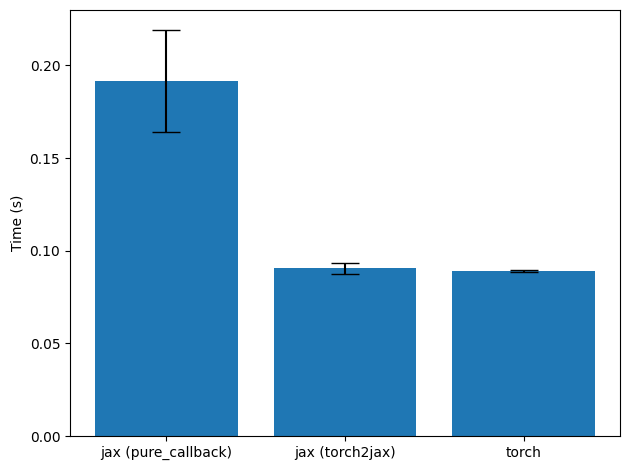

In [10]:
plt.figure()
plt.bar(
    ["jax (pure_callback)", "jax (torch2jax)", "torch"],
    [np.mean(t2s), np.mean(t1s), np.mean(t3s)],
    yerr=[np.std(t2s), np.std(t1s), np.std(t3s)],
    capsize=10.0,
)
plt.ylabel("Time (s)")
plt.tight_layout()
plt.savefig("../images/bert_from_jax.png", dpi=200, bbox_inches="tight", pad_inches=0.1)
plt.show()
